In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv(r"C:\Users\deeks\OneDrive\Desktop\My Folder\archive (5).zip")


In [ ]:
df.head()

,Category,Price,Rating,Stock,Discount
0,NaN,5548.0,1.870322,NaN,0.0
1,NaN,3045.0,4.757798,NaN,38.0
2,NaN,4004.0,NaN,In Stock,0.0
3,NaN,4808.0,1.492085,NaN,33.0
4,NaN,1817.0,NaN,Out of Stock,23.0


In [8]:
df.tail()

,Category,Price,Rating,Stock,Discount
4357,NaN,4436.0,4.728335,NaN,49.0
4358,B,6236.0,NaN,Out of Stock,4.0
4359,NaN,3283.0,NaN,Out of Stock,9.0
4360,D,2999.0,4.425995,NaN,40.0
4361,NaN,NaN,2.184471,NaN,0.0


In [8]:
num_records = df.shape[0]
num_attributes = df.shape[1]

print(f"Number of records (rows): {num_records}")
print(f"Number of attributes (columns): {num_attributes}")

Number of records (rows): 4362
Number of attributes (columns): 5


In [15]:
df.isnull().sum().sum()

np.int64(6716)

In [16]:
df.isnull().stack().value_counts()

False    15094
True      6716
Name: count, dtype: int64

In [10]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("Numerical Attributes:")
print(list(numerical_cols))

print("Categorical Attributes:")
print(list(categorical_cols))

# print("" + "-"*50 +"")


print("Statistical Summary of Numerical Attributes:")
print(df[numerical_cols].describe())

Numerical Attributes:
['Price', 'Rating', 'Discount']
Categorical Attributes:
['Category', 'Stock']
Statistical Summary of Numerical Attributes:
             Price       Rating     Discount
count  4188.000000  2312.000000  3970.000000
mean   5016.970630     3.038293    24.516625
std    2839.984813     1.143074    14.347164
min     102.000000     1.000366     0.000000
25%    2628.250000     2.069490    12.000000
50%    4996.500000     3.082060    25.000000
75%    7418.000000     4.008620    37.000000
max    9999.000000     4.997818    49.000000


In [11]:
outliers = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers[col] = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {outliers[col].shape[0]} unusual values detected")

# print("\n" + "-"*50 + "\n")

Price: 0 unusual values detected
Rating: 0 unusual values detected
Discount: 0 unusual values detected


C:\Users\deeks\AppData\Local\Temp\ipykernel_19560\148215559.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col].dropna() for col in numerical_cols], labels=numerical_cols)


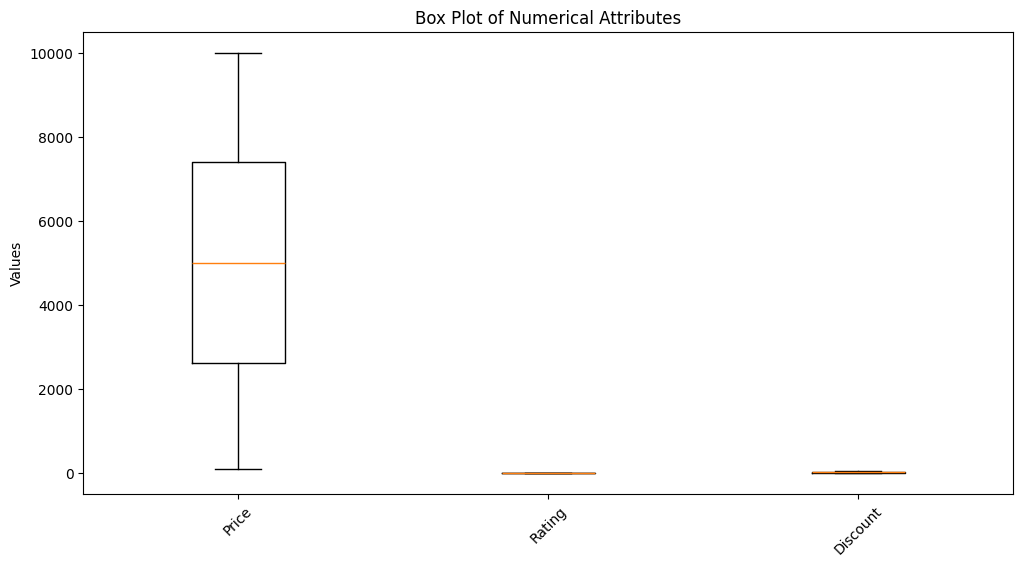

In [11]:
import pandas as pd
import matplotlib.pyplot as plt



numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns


plt.figure(figsize=(12, 6))
plt.boxplot([df[col].dropna() for col in numerical_cols], labels=numerical_cols)
plt.xticks(rotation=45)
plt.title("Box Plot of Numerical Attributes")
plt.ylabel("Values")
plt.show()

In [12]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)


for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after treatment:")
print(df.isnull().sum())

Missing values after treatment:
Category    0
Price       0
Rating      0
Stock       0
Discount    0
dtype: int64


C:\Users\deeks\AppData\Local\Temp\ipykernel_19560\308490241.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\deeks\AppData\Local\Temp\ipykernel_19560\308490241.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example